# Import
Per prima cosa è necessario eseguire l'import delle librerie utilizzate durante l'esecitazione.

In [ ]:

import keras.wrappers.scikit_learn
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import os
import time
import pandas as pd
import IPython
from scikeras import wrappers as wp
from tensorflow import keras
from sklearn.model_selection import GridSearchCV
import tensorflow_docs.modeling
import tensorflow_docs.plots
from ml_visualization import plot_confusion_matrix

## Caricamento
Il training set viene fornito sotto forma di un unico file "audio_ml2122_train.npy" contenente sia le feature che le etichette di classe delle tracce audio. La procedura per il caricamento del dataset è fornita nella cella seguente.

- Features [0:20): MFCC
- Features [20:32): Chroma (https://en.wikipedia.org/wiki/Chroma_feature)
- Features [32:160): Media dello Spettrogramma di Mel
- Features [160:167): Spectral Contrast ([paper](http://hcsi.cs.tsinghua.edu.cn/Paper/Paper02/200218.pdf))
- Features [167:173): Tonnetz ([paper](http://rose.ofai.at/~martin.gasser/papers/oefai-tr-2006-13.pdf))

In [ ]:
%reload_ext autoreload
%autoreload 2
import random
from utilities import *
seed = 1234
random.seed(seed)
np.random.seed(seed)

# Caricamento del dataset (train e test)
train_x, train_y, test_x = load_dataset()
train_x, test_x = normalize_data(train_x, test_x)

In [ ]:
from sklearn.preprocessing import RobustScaler

# Caricamento del dataset
train_dataset = np.load('DBs/AudioDigits_ML21_22/audio_ml2122_train.npy')
print('Shape del dataset:', train_dataset.shape)

# Posizione delle etichette (per il problema A si usa digit_column, per il problema B speaker_column)
digit_column = 173
speaker_column = 174

# Le ultime due colonne sono lasciate alle etichette (digit e speaker)
# train_dataset = np.concatenate((train_dataset, np.exp2(train_dataset)),axis=0)
# indexList = [np.any(i) for i in np.isnan(train_dataset)]
# train_dataset = np.delete(train_dataset, indexList, axis=0)
train_x = train_dataset[:, :-2].astype(np.float64)
train_y = train_dataset[:, digit_column].astype(int)
# validation_size = 0.25
# train_x, valid_x, train_y, valid_y = train_test_split(dataset_x, dataset_y, test_size=validation_size, random_state = 1234)
# Caricamento del dataset (test)
test_x = np.load('DBs/AudioDigits_ML21_22/audio_ml2122_test_no_labels.npy')
# dataset_x = np.concatenate((dataset_x, np.sqrt(dataset_x)),axis=0)
test_y = np.load('DBs/AudioDigits_ML21_22/audio_ml2122_test_digit_labels.npy')
print('Shape del dataset X:', test_x.shape)
print('Shape del dataset Y:', test_y.shape)

# Conversione dei dati (test)
test_x = test_x.astype(np.float32)
test_y = test_y.astype(int)

# Applica nomralizzazione con StandardScaler di scikit-learn
scaler = StandardScaler().fit(train_x)
train_x = scaler.transform(train_x)
# valid_x = scaler.transform(valid_x)

# Applica normalizzazione anche al test
test_x = scaler.transform(test_x)

In [ ]:
# Procedura di creazione del modello
inizializer = tf.keras.initializers.HeUniform(seed=seed) #tf.keras.initializers.LecunNormal(seed=42) # skipping layer
regularizer = tf.keras.regularizers.L2(0.001)
def build_model(n_features=None,lr=0.00001):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=[n_features]))
    model.add(tf.keras.layers.Dense(3000, activation='relu',kernel_regularizer =regularizer,kernel_initializer=inizializer))
    model.add(tf.keras.layers.Dense(2000, activation='relu',kernel_regularizer =regularizer,kernel_initializer=inizializer))
    model.add(tf.keras.layers.Dense(1000, activation='relu',kernel_regularizer =regularizer,kernel_initializer=inizializer))
    model.add(tf.keras.layers.Dense(500, activation='relu',kernel_regularizer =regularizer,kernel_initializer=inizializer))
    model.add(tf.keras.layers.Dense(250, activation='relu',kernel_regularizer =regularizer,kernel_initializer=inizializer))
    model.add(tf.keras.layers.Dense(31, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(lr)

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])
    return model

keras_class = wp.KerasClassifier(build_model(train_x.shape[1]))

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Nasconde messaggi di debug
os.environ["CUDA_VISIBLE_DEVICES"] = '1'  # Rende visibile solo la GPU 0
# Import TensorFlow 2.x
import tensorflow as tf
import os
import tensorflow_docs as tfdocs
import tensorflow_docs.modeling
import tensorflow_docs.plots
from tensorflow.python.client import device_lib
print('Tensorflow Version', tf.__version__)

# Mostra i dispositivi disponibili

print ("\nHardware Devices:")
print (device_lib.list_local_devices())

# Addestramento


Epoch: 0, accuracy:0.0450,  loss:17.1365,  val_accuracy:0.1905,  val_loss:16.8018,  
.....
Epoch: 5, accuracy:0.7647,  loss:15.3596,  val_accuracy:0.5952,  val_loss:15.5909,  
.....
Epoch: 10, accuracy:0.9464,  loss:14.4015,  val_accuracy:0.7619,  val_loss:14.7912,  
.....
Epoch: 15, accuracy:0.9965,  loss:13.8529,  val_accuracy:0.8571,  val_loss:14.2693,  
.....
Epoch: 20, accuracy:1.0000,  loss:13.5941,  val_accuracy:0.9524,  val_loss:14.0135,  
.....
Epoch: 25, accuracy:1.0000,  loss:13.4597,  val_accuracy:0.9762,  val_loss:13.8232,  
.....
Epoch: 30, accuracy:1.0000,  loss:13.3732,  val_accuracy:0.9762,  val_loss:13.7105,  
.....
Epoch: 35, accuracy:1.0000,  loss:13.3033,  val_accuracy:0.9762,  val_loss:13.6199,  
.....
Epoch: 40, accuracy:1.0000,  loss:13.2386,  val_accuracy:0.9762,  val_loss:13.5289,  
.....
Epoch: 45, accuracy:1.0000,  loss:13.1749,  val_accuracy:0.9762,  val_loss:13.4447,  
.....
Epoch: 50, accuracy:1.0000,  loss:13.1103,  val_accuracy:0.9762,  val_loss:13.363

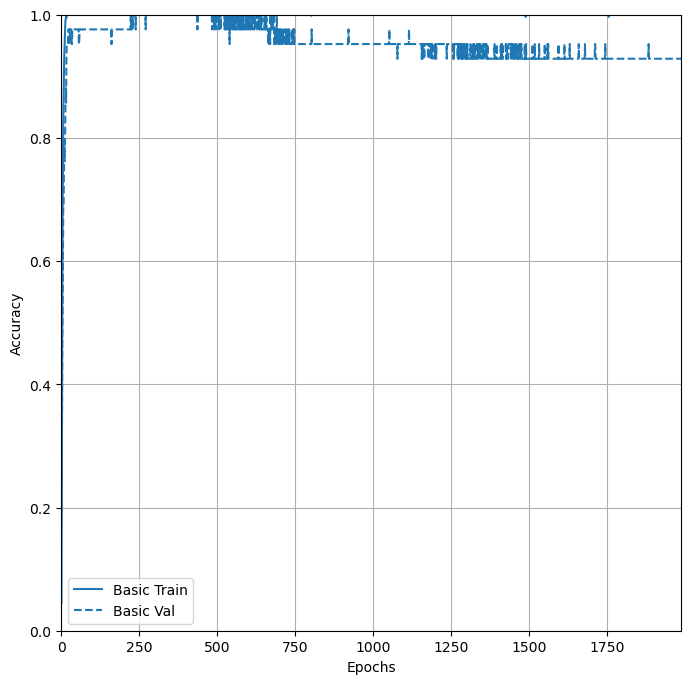

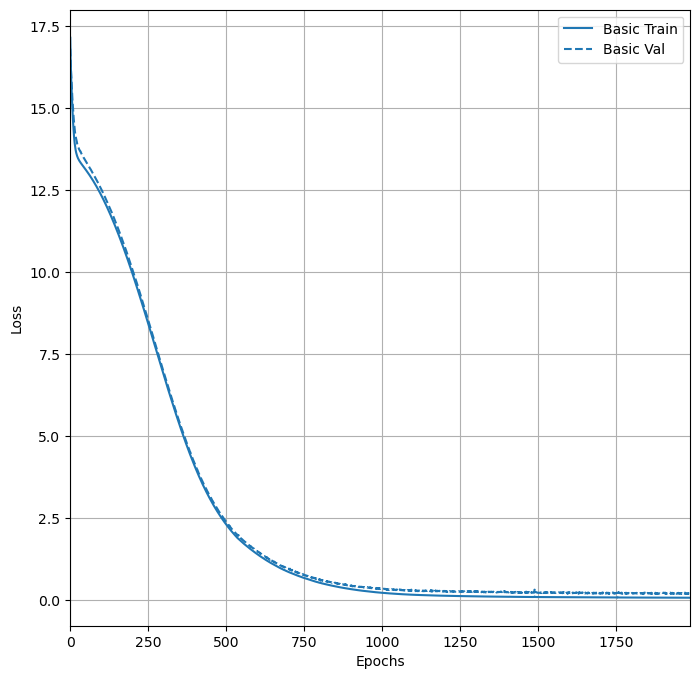


Epoch: 0, accuracy:0.9948,  loss:0.0994,  val_accuracy:1.0000,  val_loss:0.1053,  
.....
Epoch: 5, accuracy:1.0000,  loss:0.0865,  val_accuracy:1.0000,  val_loss:0.0882,  
.....
Epoch: 10, accuracy:1.0000,  loss:0.0858,  val_accuracy:1.0000,  val_loss:0.0877,  
.....
Epoch: 15, accuracy:1.0000,  loss:0.0853,  val_accuracy:1.0000,  val_loss:0.0885,  
.....
Epoch: 20, accuracy:1.0000,  loss:0.0851,  val_accuracy:1.0000,  val_loss:0.0884,  
.....
Epoch: 25, accuracy:1.0000,  loss:0.0850,  val_accuracy:1.0000,  val_loss:0.0891,  
.....
Epoch: 30, accuracy:1.0000,  loss:0.0848,  val_accuracy:1.0000,  val_loss:0.0898,  
.....
Epoch: 35, accuracy:1.0000,  loss:0.0848,  val_accuracy:1.0000,  val_loss:0.0895,  
.....
Epoch: 40, accuracy:1.0000,  loss:0.0850,  val_accuracy:1.0000,  val_loss:0.0904,  
.....
Epoch: 45, accuracy:1.0000,  loss:0.0843,  val_accuracy:1.0000,  val_loss:0.0907,  
.....
Epoch: 50, accuracy:1.0000,  loss:0.0852,  val_accuracy:1.0000,  val_loss:0.0881,  
.....
Epoch: 55, 

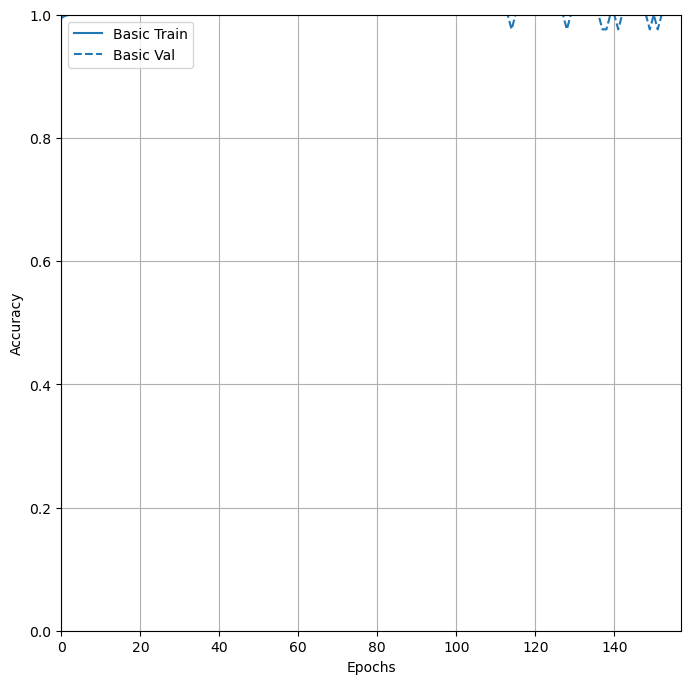

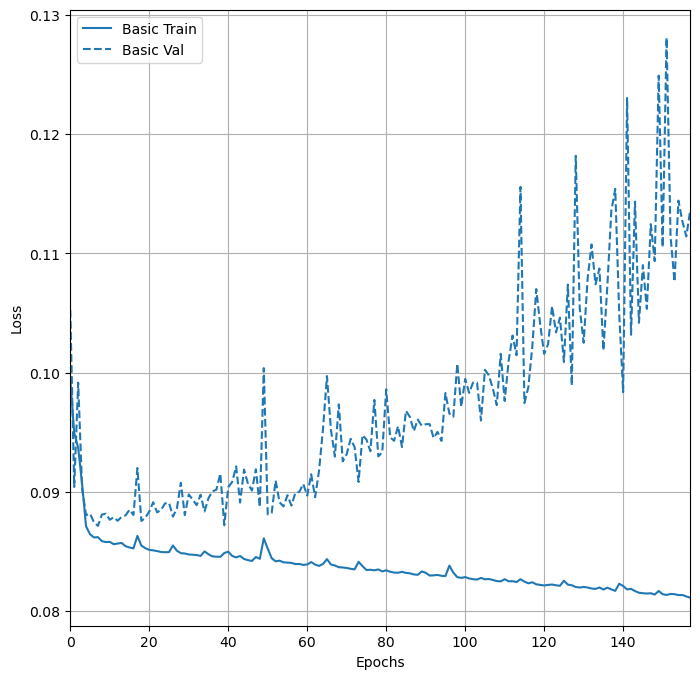


Epoch: 0, accuracy:1.0000,  loss:0.0862,  val_accuracy:1.0000,  val_loss:0.0886,  
.....
Epoch: 5, accuracy:1.0000,  loss:0.0854,  val_accuracy:1.0000,  val_loss:0.0876,  
.....
Epoch: 10, accuracy:1.0000,  loss:0.0851,  val_accuracy:1.0000,  val_loss:0.0891,  
.....
Epoch: 15, accuracy:1.0000,  loss:0.0846,  val_accuracy:1.0000,  val_loss:0.0899,  
.....
Epoch: 20, accuracy:1.0000,  loss:0.0846,  val_accuracy:1.0000,  val_loss:0.0908,  
.....
Epoch: 25, accuracy:1.0000,  loss:0.0845,  val_accuracy:1.0000,  val_loss:0.0925,  
.....
Epoch: 30, accuracy:1.0000,  loss:0.0839,  val_accuracy:1.0000,  val_loss:0.0966,  
.....
Epoch: 35, accuracy:1.0000,  loss:0.0837,  val_accuracy:1.0000,  val_loss:0.0971,  
.....
Epoch: 40, accuracy:1.0000,  loss:0.0837,  val_accuracy:1.0000,  val_loss:0.1002,  
.....
Epoch: 45, accuracy:1.0000,  loss:0.0833,  val_accuracy:1.0000,  val_loss:0.1089,  
.....
Epoch: 50, accuracy:1.0000,  loss:0.0832,  val_accuracy:1.0000,  val_loss:0.1085,  
.....
Epoch: 55, 

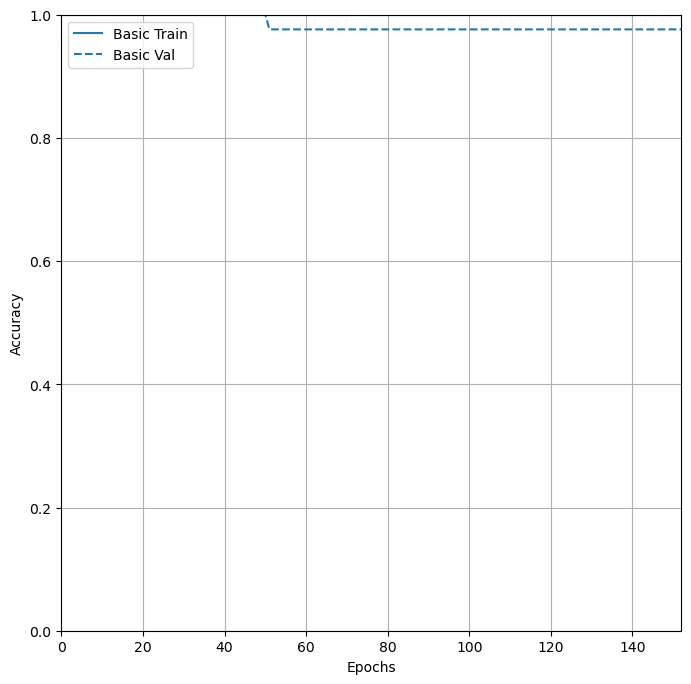

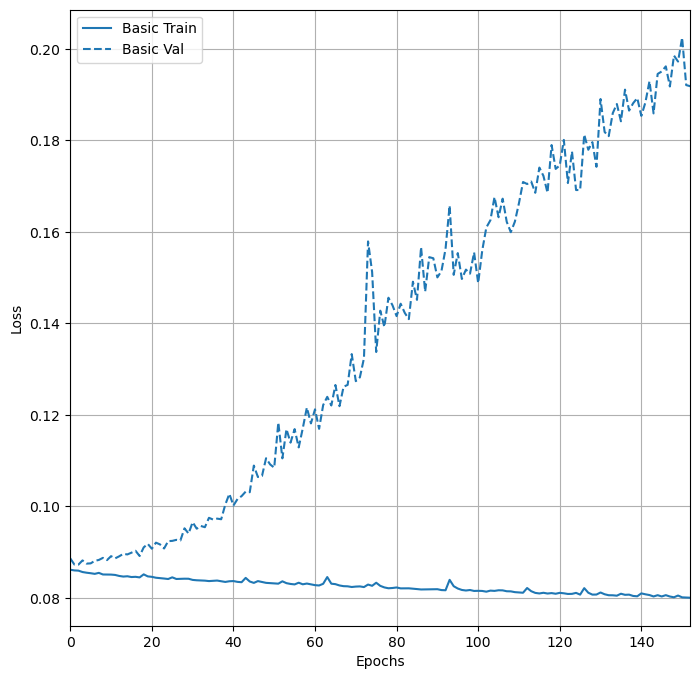


Epoch: 0, accuracy:1.0000,  loss:0.0858,  val_accuracy:1.0000,  val_loss:0.0848,  
.....
Epoch: 5, accuracy:1.0000,  loss:0.0852,  val_accuracy:1.0000,  val_loss:0.0847,  
.....
Epoch: 10, accuracy:1.0000,  loss:0.0850,  val_accuracy:1.0000,  val_loss:0.0853,  
.....
Epoch: 15, accuracy:1.0000,  loss:0.0850,  val_accuracy:1.0000,  val_loss:0.0851,  
.....
Epoch: 20, accuracy:1.0000,  loss:0.0851,  val_accuracy:1.0000,  val_loss:0.0845,  
.....
Epoch: 25, accuracy:1.0000,  loss:0.0844,  val_accuracy:1.0000,  val_loss:0.0846,  
.....
Epoch: 30, accuracy:1.0000,  loss:0.0843,  val_accuracy:1.0000,  val_loss:0.0848,  
.....
Epoch: 35, accuracy:1.0000,  loss:0.0839,  val_accuracy:1.0000,  val_loss:0.0852,  
.....
Epoch: 40, accuracy:1.0000,  loss:0.0850,  val_accuracy:1.0000,  val_loss:0.0857,  
.....
Epoch: 45, accuracy:1.0000,  loss:0.0842,  val_accuracy:1.0000,  val_loss:0.0851,  
.....
Epoch: 50, accuracy:1.0000,  loss:0.0834,  val_accuracy:1.0000,  val_loss:0.0852,  
.....
Epoch: 55, 

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold

model = build_model(train_x.shape[1])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=150, restore_best_weights=True)
left_idx = 0
kf = StratifiedKFold(n_splits=15)
for train_indices, val_indices in kf.split(train_x,train_y):
    history = model.fit(train_x[train_indices], train_y[train_indices], validation_data=(train_x[val_indices], train_y[val_indices]),
                    epochs=3000, batch_size=32, shuffle=True,
                    verbose=0, callbacks=[early_stop, tfdocs.modeling.EpochDots(report_every=5, dot_every=1)])

    plot_history(history)

La funzione *.fit(...)* restituisce l'andamento del valore numerico di diverse metriche classiche. Analizzare visivamente questi valori può essere utile per individuare eventuali anomalie e per correggere sia la struttura del modello che gli iperparametri dell'ottimizzatore.

In [ ]:
test_y = np.load('DBs/AudioDigits_ML21_22/audio_ml2122_test_digit_labels.npy')
test_y = test_y.astype(int)
test_predictions = model.predict(test_x)
test_predictions = test_predictions.argmax(axis=-1)

print('Accuratezza sul test set:', accuracy_score(test_y, test_predictions) * 100, '%')

plot_confusion_matrix(test_y, test_predictions, classes=['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine'])
# 31.290322580645164 %
# 30.32258064516129 %
# 33.87096774193548 % square
# 32.58064516129032 % selu + lecun normal uniform

# 33.5483870967742 % con relu + he uniform


Infine, **una volta ottenuta una configurazione ritenuta ottimale**, sarà possibile verificare la soluzione anche sul test set. Nella cella seguente verrà visualizzata l'accuratezza e la Confusion Matrix del modello sul test set:

In [ ]:

predictions = model.predict(test_x)
predictions = predictions.argmax(axis=-1)
np.savetxt('Es7Predictions.txt', predictions.astype(int), fmt='%i')
print('Ok')